# Principle Component Analysis and Plotting for Polar Tests

1. ### Doing regular PCA on spectral cube: ###
    - **Results**: the PCA is degenerate: cannot distinguish time scales
2. ### Doing band-pass PCA on spectral cube: ###
    - **Results**:

In [1]:
import glob
import os
from codec import CodecSystem, readPhotometry
# codec.py contains the CodecSystem class

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import pickle
from scipy.signal import savgol_filter

from matplotlib.gridspec import GridSpec
from astropy.timeseries import LombScargle
from sklearn.decomposition import PCA
from scipy.signal import butter, filtfilt

import pandas as pd
from sklearn.decomposition import PCA
from scipy.interpolate import interp1d

# make plotPaths in top directory
topDir = os.path.dirname(os.getcwd())
plotDir = os.path.join(topDir, 'paperPlots')
if not os.path.exists(plotDir):
    os.makedirs(plotDir)
print("Saving plots to ", plotDir)

# test = True
test = False

/Users/nguyendat/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/nguyendat/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


Saving plots to  /Users/nguyendat/Documents/GitHub/polarVortexJwst/paperPlots


### Helper functions, initializations

In [2]:
### Functions to read in spectra time series data ###
# default_specConfigName = '1200k_clouds=20'
default_specConfigName = '1200K_clouds=50'

print('\n######; Imported function to read in spectra time series data')
def read_spec_codecs(photrunName, specConfigName=default_specConfigName):

    ### 1. Read in photometry results
    phot = readPhotometry(os.path.join(photometryh5dir, photrunName))

    ### 2. Read in spectra time series data + codec data
    runname = f'timeseries_{photrunName[:-3]}_{specConfigName}'
    dirPath = os.path.join(os.getcwd(), runname)

    # Search for files matching the pattern 'i=*.h5' in the directory
    spectra_files = sorted(glob.glob(os.path.join(dirPath, 'composite*.h5')))
    codec_files = sorted(glob.glob(os.path.join(dirPath, 'codec*.h5')))

    # Initialize the specs dictionary
    specs = {}
    codecs = {}

    # Iterate through each inclination file and load spectra
    for index, file in enumerate(spectra_files):
        inclin = os.path.basename(file).split('=')[1].split('.')[0]  # Extract 'i' value from the filename

        specs[inclin] = CodecSystem.load_spectra_ts_h5(file)
        codecs[inclin] = CodecSystem.load_codec_images_h5(codec_files[index])

    ### 3. Load codec configuration
    configPath = glob.glob(os.path.join(dirPath, 'codec_config.json'))[0]
    codec_loaded = CodecSystem()
    codec_loaded.import_mapping(configPath, validate_files=False)
    
    return phot, specs, codecs, codec_loaded

### Load the full picaso result summary

# Search for .csv files in the specified directory
dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/'
# specFolderName = 'bd_grid_20251108_162457_all5condensates'
# specFolderName = 'bd_grid_20251202_simple3clouds'
# specFolderName = 'bd_grid_noCH4_20251209_153457'
specFolderName = 'bd_grid_noCH4_n=50_20260322_193125'

specpath = os.path.join(dir, specFolderName)
specSummary = pickle.load(open(os.path.join(specpath, 'results_summary.pkl'), 'rb'))

modelID_list = [picasomodelfile['model_id'] for picasomodelfile in specSummary]
print(f"\nFound {len(modelID_list)} model IDs in the summary:")
print(modelID_list)
print("\nSample params file: ")
print(specSummary[0]['params'])

# fsed_list
fsed_list = []
# Loop through all codec_id and get fsed
for picasomodelfile in specSummary:
    fsed = picasomodelfile['params'].get('fsed', None)
    modelid = picasomodelfile['model_id']
    fsed_list.append((modelid, fsed))

# calculate binned flux at given wavelength range (take a spectra timeseries array per inclination)
print("\n#####; Imported function for calculating binned flux")
def calculate_wavebin_flux(specs_inclin, wmin, wmax):
        flux_ts = []
        for keys in specs_inclin:
            frame_i, wave_i, flux_i = specs_inclin[keys].values()
            # Find wavelength indices in the bin
            mask = (wave_i >= wmin) & (wave_i <= wmax)
            if np.sum(mask) > 0:
                # Calculate median flux in this bin
                median_flux = np.median(flux_i[mask])
                flux_ts.append(median_flux)
        return flux_ts


######; Imported function to read in spectra time series data

Found 50 model IDs in the summary:
['bd_1200_10000_1.0000E+07_1.0000_cloudy', 'bd_1200_10000_1.0000E+07_1.0040_cloudy', 'bd_1200_10000_1.0000E+07_1.0080_cloudy', 'bd_1200_10000_1.0000E+07_1.0120_cloudy', 'bd_1200_10000_1.0000E+07_1.0160_cloudy', 'bd_1200_10000_1.0000E+07_1.0200_cloudy', 'bd_1200_10000_1.0000E+07_1.0240_cloudy', 'bd_1200_10000_1.0000E+07_1.0280_cloudy', 'bd_1200_10000_1.0000E+07_1.0320_cloudy', 'bd_1200_10000_1.0000E+07_1.0360_cloudy', 'bd_1200_10000_1.0000E+07_1.0400_cloudy', 'bd_1200_10000_1.0000E+07_1.0440_cloudy', 'bd_1200_10000_1.0000E+07_1.0480_cloudy', 'bd_1200_10000_1.0000E+07_1.0520_cloudy', 'bd_1200_10000_1.0000E+07_1.0560_cloudy', 'bd_1200_10000_1.0000E+07_1.0600_cloudy', 'bd_1200_10000_1.0000E+07_1.0640_cloudy', 'bd_1200_10000_1.0000E+07_1.0680_cloudy', 'bd_1200_10000_1.0000E+07_1.0720_cloudy', 'bd_1200_10000_1.0000E+07_1.0760_cloudy', 'bd_1200_10000_1.0000E+07_1.0800_cloudy', 'bd_1200_10000_1.0

### Importing simulated timeseries of 60-hour baselines case.

In [3]:

### Read the photometry file
photometryh5dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/'

### Test-dataset: 

# 60 hours baseline, static pole: Test Static (ts)
# photrunName_ts = 'test_polar_v0_static.h5'
photrunName_ts = 'test_polar_v2_static.h5'
phot_ts, specs_ts, codecs_ts, codec_loaded_ts = read_spec_codecs(photrunName_ts) 
time_ts = phot_ts['0']['time_array'] # load the time indices 

# 60 hours baseline, dynamic pole: Test Dynamic (td)
# photrunName_td = 'test_polar_v0_dynamic.h5'
photrunName_td = 'test_polar_v2_dynamic.h5'
phot_td, specs_td, codecs_td, codec_loaded_td = read_spec_codecs(photrunName_td) 
time_td = phot_td['0']['time_array'] # load the time indices 


Added codec 'cloud_thickness' with 50 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Generated 50 codec combinations
ID range: 0-49
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v2_static_1200K_clouds=50/codec_config.json
  Codec combinations: 50
  Spectra assignments: 50
Added codec 'cloud_thickness' with 50 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Generated 50 codec combinations
ID range: 0-49
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v2_dynamic_1200K_clouds=50/codec_config.json
  Codec combinations: 50
  Spectra assignments: 50


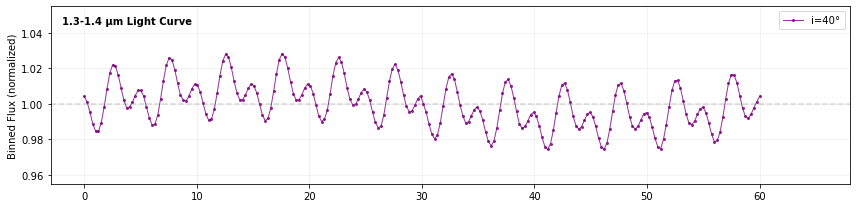

In [4]:
### Plot 1.3-1.4um light curve

# save = True
save = False 
normalize = True
codename = photrunName_ts[:-3] + '_' + default_specConfigName

fig, axs = plt.subplots(1, 1, figsize=(12, 3))
if test: fig.suptitle(codename, fontsize=6)

wavebin = [ (1.3, 1.4)]

inc_array = ['40']
markerstyles = ['o', '^', 's']
linestyles = ['-', '-', '-']
# map linestyles to wavemin and create a dictionary

# Define colors for different inclinations
colors = ['purple', 'magenta', 'orange']

for i, (wmin, wmax) in enumerate(wavebin):
    ax = axs
    for j, inclin in enumerate(inc_array):

        ### test static 
        flux_ts = calculate_wavebin_flux(specs_ts[inclin], wmin, wmax)
        
        # Plot normalized light curve
        # normalize flux mean to 1
        if normalize:
            flux_ts = np.array(flux_ts)
            flux_ts = (flux_ts - np.mean(flux_ts)) / np.max(flux_ts) + 1

        ax.plot(time_ts, flux_ts, 
                marker=markerstyles[j], linestyle=linestyles[j], 
                alpha=0.8, color=colors[j],
                linewidth=1, markersize=2+0.5*j,
                label=f'i={inclin}°')

    if i==2: ax.set_xlabel('Time (hours)', fontsize=10)

    if normalize: ax.set_ylabel('Binned Flux (normalized)')
    else: ax.set_ylabel('Binned Flux (erg/cm²/s/Hz)')

    ax.set_xlim(-3, 68)
    if normalize: ax.set_ylim(0.955, 1.055)
    ax.legend(),
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.axhline(1, ls='--', color='gray', alpha=0.3)
    ax.text(-2, 1.045, f'{wmin}-{wmax} μm Light Curve', fontsize=10, weight='bold')

plt.tight_layout()
handle = f'lightcurves_bins_{codename}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)


In [5]:
### Convert to dataframe for PCA

# For static 60-hour dataset
specs_ts_df = {}
for inc in specs_ts.keys():
    wave = specs_ts[inc][0]['wave'] # Pick any inclination key to build the DataFrame
    # (wave is the same across all time indices)
    flux = np.array([specs_ts[inc][t]['flux'] for t in sorted(specs_ts[inc].keys())])
    df = pd.DataFrame(np.vstack([wave[np.newaxis, :], flux]))
    df.index = ['wave'] + sorted(specs_ts[inc].keys())
    specs_ts_df[inc] = df

# For dynamic 60-hour dataset
specs_td_df = {}
for inc in specs_td.keys():
    wave = specs_td[inc][0]['wave'] # Pick any inclination key to build the DataFrame
    # (wave is the same across all time indices)
    flux = np.array([specs_td[inc][t]['flux'] for t in sorted(specs_td[inc].keys())])
    df = pd.DataFrame(np.vstack([wave[np.newaxis, :], flux]))
    df.index = ['wave'] + sorted(specs_td[inc].keys())
    specs_td_df[inc] = df

specs_ts_df['0'].head(25)

,0,1,2,3,4,5,6,7,8,9,...,1245,1246,1247,1248,1249,1250,1251,1252,1253,1254
wave,9.995744e-01,1.001003e+00,1.002434e+00,1.003867e+00,1.005303e+00,1.006740e+00,1.008179e+00,1.009620e+00,1.011064e+00,1.012509e+00,...,5.918873e+00,5.927334e+00,5.935808e+00,5.944294e+00,5.952792e+00,5.961302e+00,5.969824e+00,5.978358e+00,5.986905e+00,5.995464e+00
0,3.715666e-09,3.750209e-09,3.795795e-09,3.837395e-09,3.887505e-09,3.932808e-09,3.983000e-09,4.030874e-09,4.076041e-09,4.126119e-09,...,3.601477e-07,4.068229e-07,2.626351e-07,3.268028e-07,3.054040e-07,4.617433e-07,3.273094e-07,4.297180e-07,3.539820e-07,4.048231e-07
1,3.715578e-09,3.750120e-09,3.795705e-09,3.837304e-09,3.887413e-09,3.932715e-09,3.982906e-09,4.030778e-09,4.075945e-09,4.126022e-09,...,3.601472e-07,4.068222e-07,2.626349e-07,3.268026e-07,3.054038e-07,4.617423e-07,3.273090e-07,4.297172e-07,3.539814e-07,4.048222e-07
2,3.718197e-09,3.752762e-09,3.798376e-09,3.840002e-09,3.890145e-09,3.935475e-09,3.985699e-09,4.033603e-09,4.078799e-09,4.128908e-09,...,3.601621e-07,4.068437e-07,2.626397e-07,3.268121e-07,3.054123e-07,4.617747e-07,3.273215e-07,4.297435e-07,3.539992e-07,4.048480e-07
3,3.718277e-09,3.752842e-09,3.798458e-09,3.840084e-09,3.890228e-09,3.935559e-09,3.985784e-09,4.033689e-09,4.078886e-09,4.128996e-09,...,3.601625e-07,4.068443e-07,2.626398e-07,3.268123e-07,3.054125e-07,4.617756e-07,3.273218e-07,4.297442e-07,3.539997e-07,4.048487e-07
4,3.720959e-09,3.755548e-09,3.801194e-09,3.842847e-09,3.893026e-09,3.938386e-09,3.988645e-09,4.036582e-09,4.081808e-09,4.131951e-09,...,3.601774e-07,4.068659e-07,2.626446e-07,3.268219e-07,3.054211e-07,4.618083e-07,3.273344e-07,4.297708e-07,3.540177e-07,4.048746e-07
5,3.721048e-09,3.755638e-09,3.801285e-09,3.842938e-09,3.893118e-09,3.938479e-09,3.988740e-09,4.036678e-09,4.081904e-09,4.132049e-09,...,3.601779e-07,4.068666e-07,2.626448e-07,3.268222e-07,3.054214e-07,4.618094e-07,3.273348e-07,4.297716e-07,3.540183e-07,4.048755e-07
6,3.724017e-09,3.758633e-09,3.804313e-09,3.845996e-09,3.896214e-09,3.941608e-09,3.991906e-09,4.039879e-09,4.085138e-09,4.135320e-09,...,3.601944e-07,4.068904e-07,2.626500e-07,3.268327e-07,3.054308e-07,4.618453e-07,3.273485e-07,4.298008e-07,3.540380e-07,4.049040e-07
7,3.724166e-09,3.758783e-09,3.804465e-09,3.846150e-09,3.896370e-09,3.941765e-09,3.992065e-09,4.040040e-09,4.085301e-09,4.135484e-09,...,3.601952e-07,4.068916e-07,2.626503e-07,3.268333e-07,3.054313e-07,4.618471e-07,3.273492e-07,4.298023e-07,3.540390e-07,4.049055e-07
8,3.724531e-09,3.759151e-09,3.804838e-09,3.846526e-09,3.896751e-09,3.942150e-09,3.992454e-09,4.040433e-09,4.085699e-09,4.135887e-09,...,3.601972e-07,4.068945e-07,2.626510e-07,3.268345e-07,3.054324e-07,4.618514e-07,3.273509e-07,4.298058e-07,3.540414e-07,4.049089e-07


### Plot spectral cube for `static` case for inclination 90

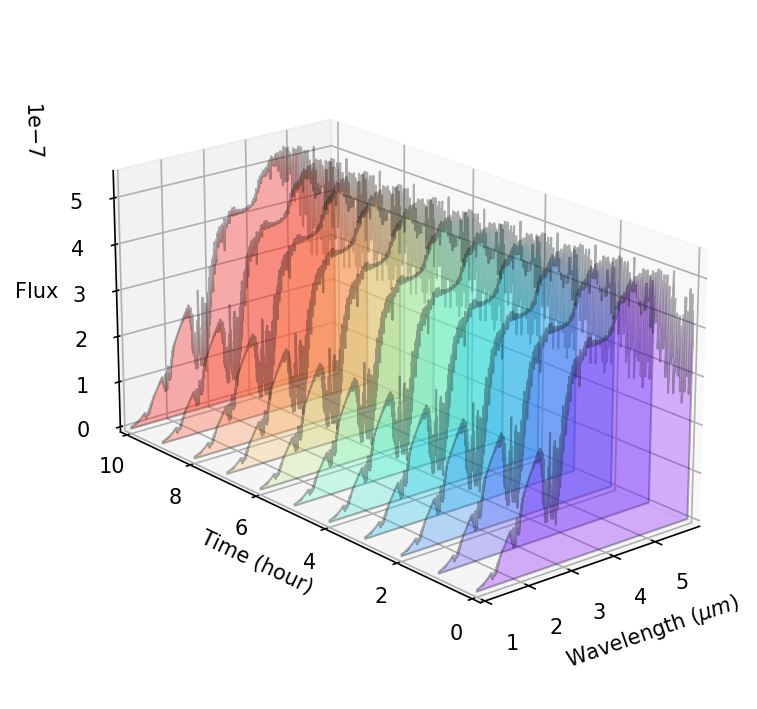

In [6]:
from matplotlib.collections import PolyCollection
from matplotlib import cm
viridis = cm.get_cmap('rainbow_r', 12)

# normalize_to_reference = True  # set to False to plot raw fluxes
normalize_to_reference = False  # set to False to plot raw fluxes

def polygon_under_graph(x, y):
    """
    Construct the vertex list which defines the polygon filling the space under
    the (x, y) line graph. This assumes x is in ascending order.
    """
    return [(x[0], 0.), *zip(x, y), (x[-1], 0.)]

# Pick an inclination
incl_key = '90'

# Extract wave (first row) and flux rows (all remaining rows)
wave = specs_ts_df[incl_key] .iloc[0].values.astype(float)

if normalize_to_reference:
    flux_raw = specs_ts_df[incl_key] .iloc[1:].values.astype(float)
    reference = flux_raw[60]  # or use np.mean(flux_raw, axis=0) for mean-normalized
    flux_df = (flux_raw - reference)/reference  # now 0 = no change, ±0.1 = ±10%

else: flux_df = specs_ts_df[incl_key] .iloc[1:].values.astype(float)

# Control which time steps to plot and spacing
n_steps = 11          # number of time steps to plot
skip = 1             # skip every N time steps
time_indices = list(range(0, n_steps * skip, skip))  # e.g. [0, 6, 12, 18, ...]

# Build polygons from the selected time steps
verts = [polygon_under_graph(wave, flux_df[t]) for t in time_indices]
labels = [t/skip for t in time_indices]  # for y-axis positioning

facecolors = viridis(np.linspace(0, 1, len(verts)))
poly = PolyCollection(verts, facecolors=facecolors, edgecolors=("black"), alpha=.3)

ax = plt.figure(figsize=(15,6), dpi=150).add_subplot(projection='3d')
ax.view_init(elev=20, azim=50)  # adjust azim to rotate left-right
ax.set_box_aspect([1, 2, 1])  # [wavelength, time step, flux]

ax.add_collection3d(poly, zs=np.flip(labels), zdir='y')

ax.set(
    xlim=(wave.max(), wave.min()),
    ylim=(max(labels), min(labels)),
    zlim=(0, flux_df.max()),
    xlabel=r'Wavelength $(\mu m)$',
    ylabel='Time (hour)',
    zlabel='Flux'
)
plt.show()

In [7]:
# find the time-median spectrum across the time series
# Pick an inclination
incl_key = '60'

# do a median on data frame across time steps
wave = specs_ts_df[incl_key] .iloc[0].values.astype(float)
flux = specs_ts_df[incl_key] .iloc[1:].values.astype(float)
median_spectrum = np.median(flux, axis=0)

# plot the max and min spectrum at t argmax and t argmin
max_index = np.argmax(np.sum(flux, axis=1))
min_index = np.argmin(np.sum(flux, axis=1))

### Plot interactive bokeh plot
from bokeh.plotting import figure, show, output_notebook
output_notebook()

p = figure(x_axis_label='Wave',
           y_axis_label='Flux',
           y_axis_type='linear',
           width = 800, height = 400)

p.line(wave, median_spectrum, color='blue', legend_label='Median spectrum')
p.line(wave, flux[max_index], color='red', legend_label=f'Max spectrum at t={max_index/2} hr')
p.line(wave, flux[min_index], color='green', legend_label=f'Min spectrum at t={min_index/2} hr')

p.legend.location = "top_left"

show(p)


Loading BokehJS ...

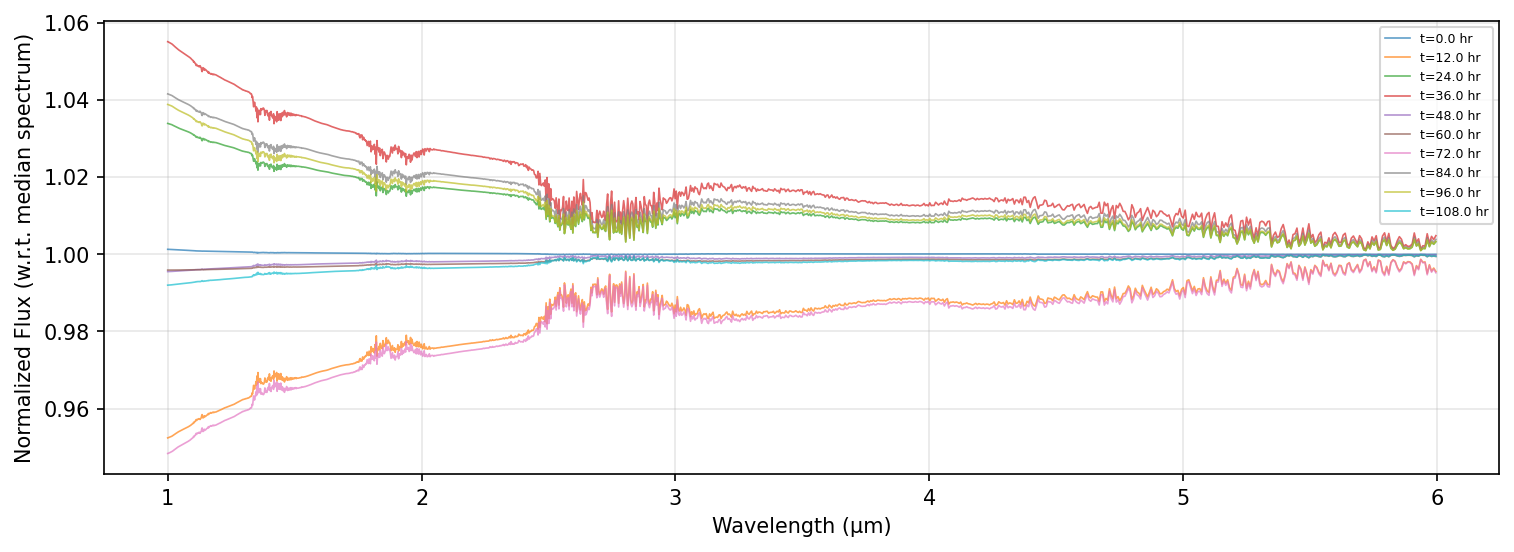

In [8]:
### divide flux by the median spectrum
flux = specs_ts_df[incl_key] .iloc[1:].values.astype(float)
median_spectrum = np.median(flux, axis=0)
flux_normalized = flux / median_spectrum[np.newaxis, :]

### plot some spectra from the normalized flux matrix
plt.figure(figsize=(12,4), dpi=150)
indexs = np.arange(0, flux_normalized.shape[0], int(flux_normalized.shape[0]/10))
for idx in indexs:
    plt.plot(wave, flux_normalized[idx], alpha=0.7, lw=0.8, label=f't={idx/2} hr')
plt.xlabel('Wavelength (μm)')
plt.ylabel('Normalized Flux (w.r.t. median spectrum)')
plt.legend(fontsize=6)
plt.grid(True, alpha=0.3)

## 1. Doing regular PCA on spectral cube

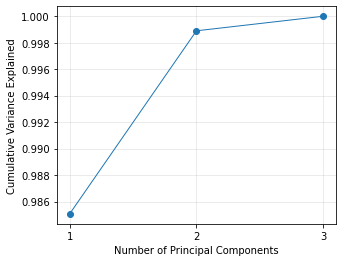

In [9]:
### Doing standard scaling (mean=0, std=1) on each wavelength bin
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
flux_scaled = scaler.fit_transform(flux_normalized.T).T  # transpose to scale each wavelength bin

### Doing PCA on the normalized flux matrix and plot cummulative variance explained
pca = PCA(n_components=3)
pca.fit(flux_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(5,4))
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance, marker='o', lw=1)
plt.xticks(np.arange(1, len(cumulative_variance)+1))
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
# make y axis E formatted
# plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

Relative variance in principal components: [9.99904346e-01 9.56494679e-05 4.47428733e-09]


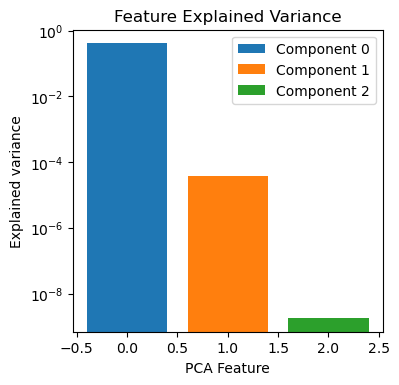

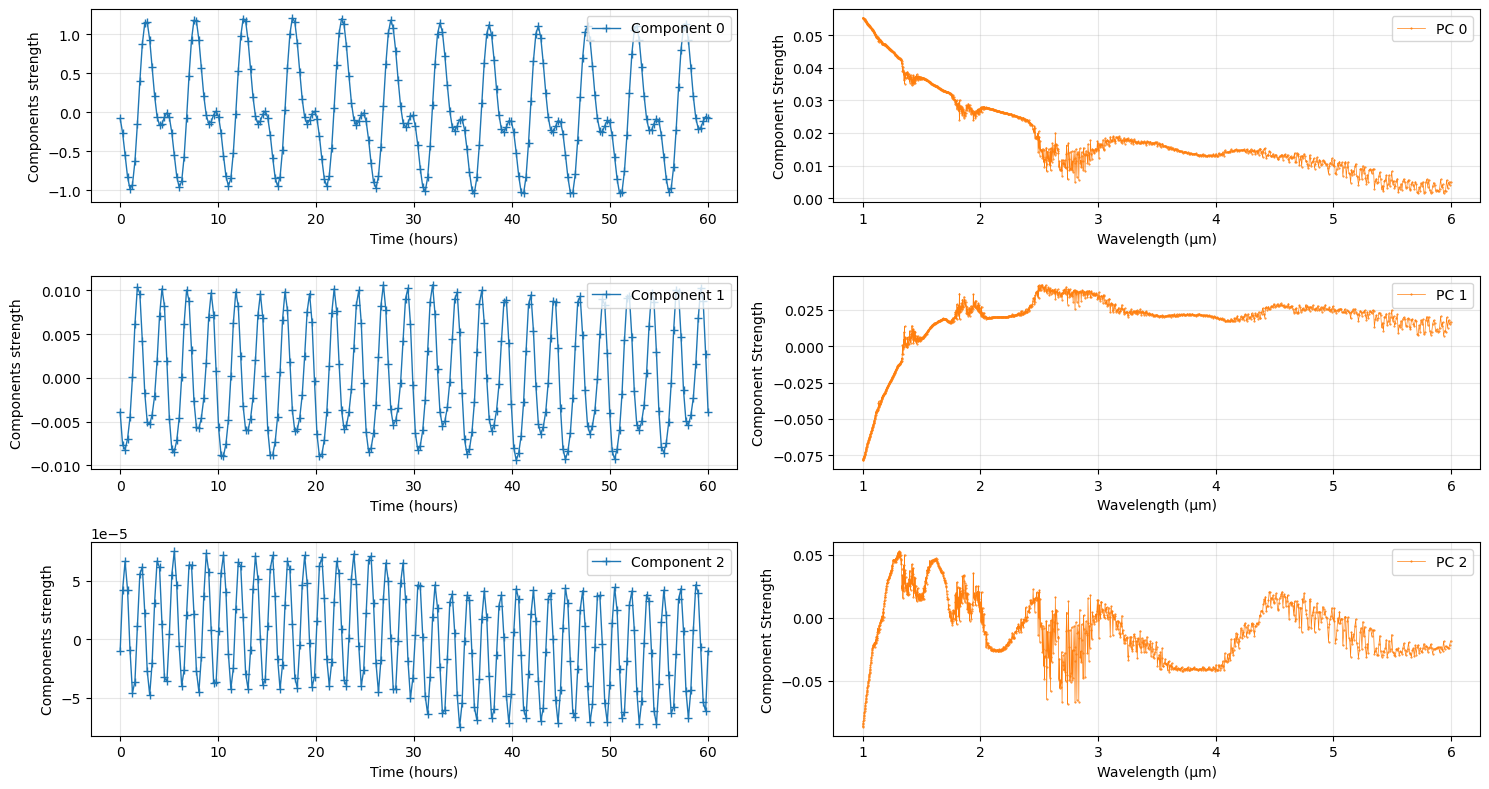

In [10]:
### Redo PCA for 3 components and plot all the component in flux and wavelength space
# pca = PCA(n_components=0.9999)
pca = PCA(n_components=3)
pca.fit(flux_normalized)
X_pca = pca.transform(flux_normalized)

print("Relative variance in principal components:", pca.explained_variance_ratio_)
# Bar plot of explained_variance
plt.figure(figsize=(4,4),dpi=100)
for i, variance in enumerate(pca.explained_variance_):
    plt.bar(i, variance, label='Component %i'%i)
plt.xlabel('PCA Feature'), plt.ylabel('Explained variance'), plt.legend(loc='upper right')
plt.title('Feature Explained Variance'),
plt.yscale('log')
plt.show()
plt.close()

fig, axs = plt.subplots(3,2,figsize=(15, 8),dpi=100)
for i, comp in enumerate(np.transpose(X_pca)):
    # print(comp)
    axs[i,0].plot(time_ts, comp, ls='-', marker='+', ms=6, lw=1, label='Component %i'%i)
    axs[i,0].set_xlabel('Time (hours)')
    axs[i,0].set_ylabel('Components strength')
    axs[i,0].legend(loc='upper right')
    axs[i,0].grid(True, alpha=0.3)

    axs[i,1].plot(wave, pca.components_[i], c='tab:orange', 
                ls='-', marker='o', ms=0.5, lw=0.5, label='PC %i'%i)
    axs[i,1].set_xlabel('Wavelength (μm)')
    axs[i,1].set_ylabel('Component Strength')
    axs[i,1].legend(loc='upper right')
    axs[i,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Doing bandpass PCA on spectral cube of i = 30, 60

### 2A. Bandpass periodogram PCA for i=20

In [18]:
### Do similar periodogram analysis for dynamic 60-hour dataset at i=20°

incl_key = '20'
specs_ts_df[incl_key]  = specs_ts_df[incl_key] 
wave = specs_ts_df[incl_key] .iloc[0].values.astype(float)
flux_i = specs_ts_df[incl_key] .iloc[1:].values.astype(float)
median_spectrum_i = np.median(flux_i, axis=0)
flux_normalized_i = flux_i / median_spectrum_i[np.newaxis, :]

# PCA
pca_i = PCA(n_components=3)
pca_i.fit(flux_normalized_i)
X_pca_i = pca_i.transform(flux_normalized_i)

### Do periodogram analysis for static 60-hour dataset at i=20° 
periods = np.linspace(0.5, 100, 2000)      # hours
freqs   = 1.0 / periods                    # cycles / hour

n_frames, n_wave = flux_i.shape
powers_i = np.zeros((n_wave, len(periods)))  # (1255, 2000)

for i in range(n_wave):
    lc = flux_normalized_i[:, i] - 1.0       # subtract baseline
    ls = LombScargle(time_ts, lc)
    powers_i[i, :] = ls.power(freqs)

# regular PCA on the periodogram powers
pca_pg = PCA(n_components=5)
pg_scores = pca_pg.fit_transform(powers_i)     # (1255, 5)
# ─── BANDPASS FILTER + PCA (fallback if periodogram PCA is degenerate) ────
dt   = time_ts[1] - time_ts[0]              # 0.5 hr
fs   = 1.0 / dt                             # 2 cycles/hr (sampling freq)
nyq  = fs / 2.0                             # 1 cycle/hr

def bandpass(data_1d, lo_period, hi_period, fs, nyq, order=2):
    """Butter bandpass on a single light curve. lo/hi are in hours (period)."""
    lo_freq = 1.0 / hi_period   # lower freq edge
    hi_freq = 1.0 / lo_period   # upper freq edge
    b, a = butter(order, [lo_freq / nyq, hi_freq / nyq], btype='band')
    return filtfilt(b, a, data_1d)

# 5-hr mode: keep periods 3–8 hr  (centred on 5 hr)
# 60-hr mode: keep periods 20–100 hr  (centred on 60 hr, upper = Nyquist-ish)
filtered_5h  = np.zeros_like(flux_normalized_i)            # (120, 1255)
filtered_60h = np.zeros_like(flux_normalized_i)            # (120, 1255)

band1_low, band1_high = 2, 20       # hours
band2_low, band2_high = 40, 80     # hours

for i in range(n_wave):
    lc = flux_normalized_i[:, i] - 1.0
    filtered_5h[:, i]  = bandpass(lc,  band1_low,  band1_high,  fs, nyq)
    filtered_60h[:, i] = bandpass(lc, band2_low, band2_high,  fs, nyq)

# PCA on each filtered cube  (rows = frames, cols = wave → transpose for "spectral PCA")
# We want to find the *spectral shape* of each mode, so we PCA across wavelength.
# Transpose: (1255 wave × 120 frames) so each row is a wavelength's filtered LC.
pca_5h  = PCA(n_components=3)
scores_5h  = pca_5h.fit_transform(filtered_5h.T)   # (1255, 3)

pca_60h = PCA(n_components=3)
scores_60h = pca_60h.fit_transform(filtered_60h.T) # (1255, 3)


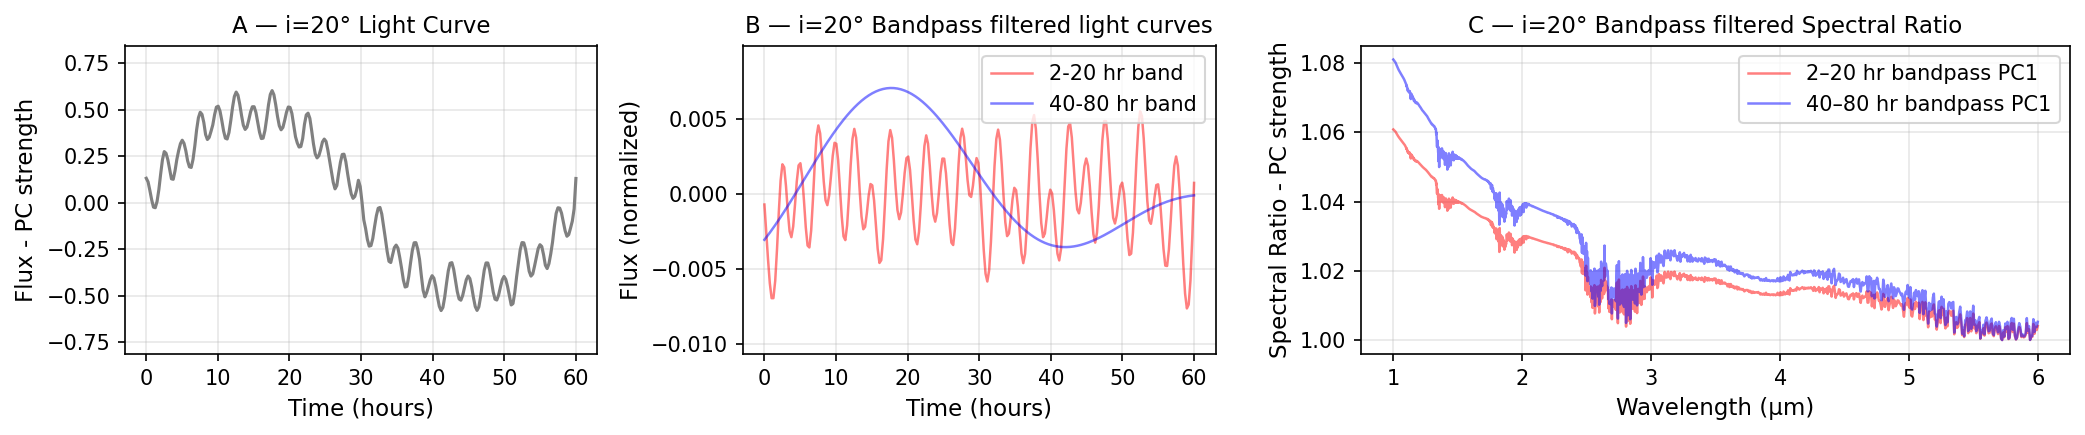

In [19]:
### Plot periodogram analysis for static 60-hour dataset
save = True 
# save = False

fig, axs = plt.subplots(1, 3, figsize=(14, 3), dpi=150, gridspec_kw={'width_ratios': [1, 1, 1.5]})

# plot periodogram of 1.35um light curve
idx_1 = np.argmin(np.abs(wave - 1.35))

# --- Panel A: Periodograms ---
# ax = axs[0]
# lc_1 = flux_normalized_i[:, idx_1] - 1.0
# ls_1 = LombScargle(time_ts, lc_1)
# power_1 = ls_1.power(freqs)
# ax.plot(periods, power_1, color="gray", lw=1.5)
# ax.set_xlabel("Period (hours)", fontsize=11)
# ax.set_ylabel("Lomb-Scargle Power", fontsize=11)
# ax.set_title(f"A — i={incl_key}° Periodogram 1.3-1.4 µm", fontsize=11)
# # draw box around 3-8 hr and 20-100 hr regions
# ax.axvspan(band1_low, band1_high, color='r', alpha=0.1, label=f"{band1_low}-{band1_high} hr band")
# ax.axvspan(band2_low, band2_high, color='b', alpha=0.1, label=f"{band2_low}-{band2_high} hr band")
# ax.legend(fontsize=8)

# --- Panel B: First PCA component over time
ax = axs[0]
pc1_time = X_pca_i[:, 0]
from scipy.signal import savgol_filter
ax.plot(time_ts, savgol_filter(pc1_time, window_length=5, polyorder=3), 
        color="gray", lw=1.5)
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Flux - PC strength", fontsize=11)
ax.set_title(f"A — i={incl_key}° Light Curve", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(1.4*pc1_time.min(), 1.4*pc1_time.max())

# --- Panel C: Bandpass filtered light curves over two bands
ax = axs[1]
lc_5h_1 = filtered_5h[:, idx_1]
lc_60h_1 = filtered_60h[:, idx_1]
ax.plot(time_ts, lc_5h_1,  color="red", lw=1.2, alpha=0.5, label=f"{band1_low}-{band1_high} hr band")
ax.plot(time_ts, lc_60h_1, color="blue", lw=1.2, alpha=0.5, label=f"{band2_low}-{band2_high} hr band")
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Flux (normalized)", fontsize=11)
ax.set_title(f"B — i={incl_key}° Bandpass filtered light curves", fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ymin = min(lc_5h_1.min(), lc_60h_1.min())
ymax = max(lc_5h_1.max(), lc_60h_1.max())
ax.set_ylim(1.4 * ymin, 1.4 * ymax)

plt.tight_layout()

# --- Panel D: PCA over wavelengths of bandpass filtered data ---
ax = axs[2]
# use the first PCA component from each bandpass filtered data
score_60h_pc1 = scores_60h[:, 0]
score_5h_pc1 = scores_5h[:, 0]

# flip y axis of 5h score and move minimum to 0
score_5h_pc1 = 1+ score_5h_pc1 - np.min(score_5h_pc1) 
# move minimum of 60h score to 0
score_60h_pc1 = 1+ score_60h_pc1 - np.min(score_60h_pc1)
ax.grid(True, alpha=0.3)
ax.plot(wave, score_5h_pc1,  color="red", lw=1.2, alpha=0.5, label=f"{band1_low}–{band1_high} hr bandpass PC1")
ax.plot(wave, score_60h_pc1, color="blue", lw=1.2, alpha=0.5, label=f"{band2_low}–{band2_high} hr bandpass PC1")
ax.set_xlabel("Wavelength (µm)", fontsize=11)
ax.set_ylabel("Spectral Ratio - PC strength", fontsize=11)
ax.set_title(f"C — i={incl_key}° Bandpass filtered Spectral Ratio", fontsize=11)
ax.legend(fontsize=10, loc='upper right')


plt.tight_layout()
if save:
    handle = f'PCA_i={incl_key}_bandpass_filter.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=500, bbox_inches='tight')
plt.show()
plt.close(fig)

### 2B. Bandpass periodogram PCA for i=40

In [20]:
### Do similar periodogram analysis for dynamic 60-hour dataset at i=20°

incl_key = '40'
specs_ts_df[incl_key]  = specs_ts_df[incl_key] 
wave = specs_ts_df[incl_key] .iloc[0].values.astype(float)
flux_i = specs_ts_df[incl_key] .iloc[1:].values.astype(float)
median_spectrum_i = np.median(flux_i, axis=0)
flux_normalized_i = flux_i / median_spectrum_i[np.newaxis, :]

# PCA
pca_i = PCA(n_components=3)
pca_i.fit(flux_normalized_i)
X_pca_i = pca_i.transform(flux_normalized_i)

### Do periodogram analysis for static 60-hour dataset at i=20° 
periods = np.linspace(0.5, 100, 2000)      # hours
freqs   = 1.0 / periods                    # cycles / hour

n_frames, n_wave = flux_i.shape
powers_i = np.zeros((n_wave, len(periods)))  # (1255, 2000)

for i in range(n_wave):
    lc = flux_normalized_i[:, i] - 1.0       # subtract baseline
    ls = LombScargle(time_ts, lc)
    powers_i[i, :] = ls.power(freqs)

# regular PCA on the periodogram powers
pca_pg = PCA(n_components=5)
pg_scores = pca_pg.fit_transform(powers_i)     # (1255, 5)
# ─── BANDPASS FILTER + PCA (fallback if periodogram PCA is degenerate) ────
dt   = time_ts[1] - time_ts[0]              # 0.5 hr
fs   = 1.0 / dt                             # 2 cycles/hr (sampling freq)
nyq  = fs / 2.0                             # 1 cycle/hr

def bandpass(data_1d, lo_period, hi_period, fs, nyq, order=2):
    """Butter bandpass on a single light curve. lo/hi are in hours (period)."""
    lo_freq = 1.0 / hi_period   # lower freq edge
    hi_freq = 1.0 / lo_period   # upper freq edge
    b, a = butter(order, [lo_freq / nyq, hi_freq / nyq], btype='band')
    return filtfilt(b, a, data_1d)

# 5-hr mode: keep periods 3–8 hr  (centred on 5 hr)
# 60-hr mode: keep periods 20–100 hr  (centred on 60 hr, upper = Nyquist-ish)
filtered_5h  = np.zeros_like(flux_normalized_i)            # (120, 1255)
filtered_60h = np.zeros_like(flux_normalized_i)            # (120, 1255)

band1_low, band1_high = 2, 20       # hours
band2_low, band2_high = 40, 80     # hours

for i in range(n_wave):
    lc = flux_normalized_i[:, i] - 1.0
    filtered_5h[:, i]  = bandpass(lc,  band1_low,  band1_high,  fs, nyq)
    filtered_60h[:, i] = bandpass(lc, band2_low, band2_high,  fs, nyq)

# PCA on each filtered cube  (rows = frames, cols = wave → transpose for "spectral PCA")
# We want to find the *spectral shape* of each mode, so we PCA across wavelength.
# Transpose: (1255 wave × 120 frames) so each row is a wavelength's filtered LC.
pca_5h  = PCA(n_components=3)
scores_5h  = pca_5h.fit_transform(filtered_5h.T)   # (1255, 3)

pca_60h = PCA(n_components=3)
scores_60h = pca_60h.fit_transform(filtered_60h.T) # (1255, 3)


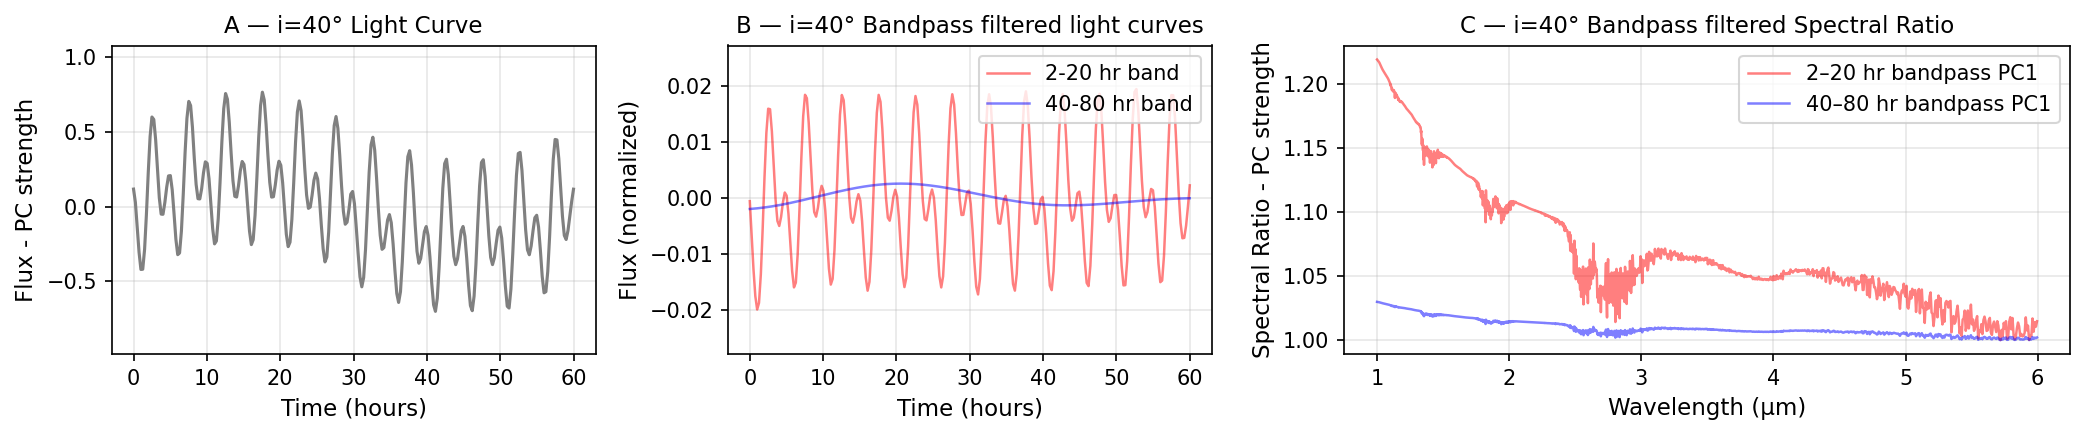

In [21]:
### Plot periodogram analysis for static 60-hour dataset
save = True 
# save = False

fig, axs = plt.subplots(1, 3, figsize=(14, 3), dpi=150, gridspec_kw={'width_ratios': [1, 1, 1.5]})

# plot periodogram of 1.35um light curve
idx_1 = np.argmin(np.abs(wave - 1.35))

# --- Panel A: Periodograms ---
# ax = axs[0]
# lc_1 = flux_normalized_i[:, idx_1] - 1.0
# ls_1 = LombScargle(time_ts, lc_1)
# power_1 = ls_1.power(freqs)
# ax.plot(periods, power_1, color="gray", lw=1.5)
# ax.set_xlabel("Period (hours)", fontsize=11)
# ax.set_ylabel("Lomb-Scargle Power", fontsize=11)
# ax.set_title(f"A — i={incl_key}° Periodogram 1.3-1.4 µm", fontsize=11)
# # draw box around 3-8 hr and 20-100 hr regions
# ax.axvspan(band1_low, band1_high, color='r', alpha=0.1, label=f"{band1_low}-{band1_high} hr band")
# ax.axvspan(band2_low, band2_high, color='b', alpha=0.1, label=f"{band2_low}-{band2_high} hr band")
# ax.legend(fontsize=8)

# --- Panel B: First PCA component over time
ax = axs[0]
pc1_time = X_pca_i[:, 0]
from scipy.signal import savgol_filter
ax.plot(time_ts, savgol_filter(pc1_time, window_length=5, polyorder=3), 
        color="gray", lw=1.5)
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Flux - PC strength", fontsize=11)
ax.set_title(f"A — i={incl_key}° Light Curve", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(1.4*pc1_time.min(), 1.4*pc1_time.max())

# --- Panel C: Bandpass filtered light curves over two bands
ax = axs[1]
lc_5h_1 = filtered_5h[:, idx_1]
lc_60h_1 = filtered_60h[:, idx_1]
ax.plot(time_ts, lc_5h_1,  color="red", lw=1.2, alpha=0.5, label=f"{band1_low}-{band1_high} hr band")
ax.plot(time_ts, lc_60h_1, color="blue", lw=1.2, alpha=0.5, label=f"{band2_low}-{band2_high} hr band")
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Flux (normalized)", fontsize=11)
ax.set_title(f"B — i={incl_key}° Bandpass filtered light curves", fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ymin = min(lc_5h_1.min(), lc_60h_1.min())
ymax = max(lc_5h_1.max(), lc_60h_1.max())
ax.set_ylim(1.4 * ymin, 1.4 * ymax)

plt.tight_layout()

# --- Panel D: PCA over wavelengths of bandpass filtered data ---
ax = axs[2]
# use the first PCA component from each bandpass filtered data
score_60h_pc1 = scores_60h[:, 0]
score_5h_pc1 = scores_5h[:, 0]

# flip y axis of 5h score and move minimum to 0
score_5h_pc1 = 1+ score_5h_pc1 - np.min(score_5h_pc1) 
# move minimum of 60h score to 0
score_60h_pc1 = 1+ score_60h_pc1 - np.min(score_60h_pc1)
ax.grid(True, alpha=0.3)
ax.plot(wave, score_5h_pc1,  color="red", lw=1.2, alpha=0.5, label=f"{band1_low}–{band1_high} hr bandpass PC1")
ax.plot(wave, score_60h_pc1, color="blue", lw=1.2, alpha=0.5, label=f"{band2_low}–{band2_high} hr bandpass PC1")
ax.set_xlabel("Wavelength (µm)", fontsize=11)
ax.set_ylabel("Spectral Ratio - PC strength", fontsize=11)
ax.set_title(f"C — i={incl_key}° Bandpass filtered Spectral Ratio", fontsize=11)
ax.legend(fontsize=10, loc='upper right')


plt.tight_layout()
if save:
    handle = f'PCA_i={incl_key}_bandpass_filter.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=500, bbox_inches='tight')
plt.show()
plt.close(fig)

### 2C. Bandpass periodogram PCA for i=80

In [22]:
### Do similar periodogram analysis for dynamic 60-hour dataset at i=90°

incl_key = '80'
specs_ts_df[incl_key]  = specs_ts_df[incl_key] 
wave = specs_ts_df[incl_key] .iloc[0].values.astype(float)
flux_i = specs_ts_df[incl_key] .iloc[1:].values.astype(float)
median_spectrum_i = np.median(flux_i, axis=0)
flux_normalized_i = flux_i / median_spectrum_i[np.newaxis, :]

# PCA
pca_i = PCA(n_components=3)
pca_i.fit(flux_normalized_i)
X_pca_i = pca_i.transform(flux_normalized_i)

### Do periodogram analysis for static 60-hour dataset at i=90° 
periods = np.linspace(0.5, 100, 2000)      # hours
freqs   = 1.0 / periods                    # cycles / hour

n_frames, n_wave = flux_i.shape
powers_i = np.zeros((n_wave, len(periods)))  # (1255, 2000)

for i in range(n_wave):
    lc = flux_normalized_i[:, i] - 1.0       # subtract baseline
    ls = LombScargle(time_ts, lc)
    powers_i[i, :] = ls.power(freqs)

# regular PCA on the periodogram powers
pca_pg = PCA(n_components=5)
pg_scores = pca_pg.fit_transform(powers_i)     # (1255, 5)
# ─── BANDPASS FILTER + PCA (fallback if periodogram PCA is degenerate) ────
dt   = time_ts[1] - time_ts[0]              # 0.5 hr
fs   = 1.0 / dt                             # 2 cycles/hr (sampling freq)
nyq  = fs / 2.0                             # 1 cycle/hr

def bandpass(data_1d, lo_period, hi_period, fs, nyq, order=2):
    """Butter bandpass on a single light curve. lo/hi are in hours (period)."""
    lo_freq = 1.0 / hi_period   # lower freq edge
    hi_freq = 1.0 / lo_period   # upper freq edge
    b, a = butter(order, [lo_freq / nyq, hi_freq / nyq], btype='band')
    return filtfilt(b, a, data_1d)

# 5-hr mode: keep periods 3–8 hr  (centred on 5 hr)
# 60-hr mode: keep periods 20–100 hr  (centred on 60 hr, upper = Nyquist-ish)
filtered_5h  = np.zeros_like(flux_normalized_i)            # (120, 1255)
filtered_60h = np.zeros_like(flux_normalized_i)            # (120, 1255)

band1_low, band1_high = 2, 20       # hours
band2_low, band2_high = 40, 80     # hours

for i in range(n_wave):
    lc = flux_normalized_i[:, i] - 1.0
    filtered_5h[:, i]  = bandpass(lc,  band1_low,  band1_high,  fs, nyq)
    filtered_60h[:, i] = bandpass(lc, band2_low, band2_high,  fs, nyq)

# PCA on each filtered cube  (rows = frames, cols = wave → transpose for "spectral PCA")
# We want to find the *spectral shape* of each mode, so we PCA across wavelength.
# Transpose: (1255 wave × 120 frames) so each row is a wavelength's filtered LC.
pca_5h  = PCA(n_components=3)
scores_5h  = pca_5h.fit_transform(filtered_5h.T)   # (1255, 3)

pca_60h = PCA(n_components=3)
scores_60h = pca_60h.fit_transform(filtered_60h.T) # (1255, 3)


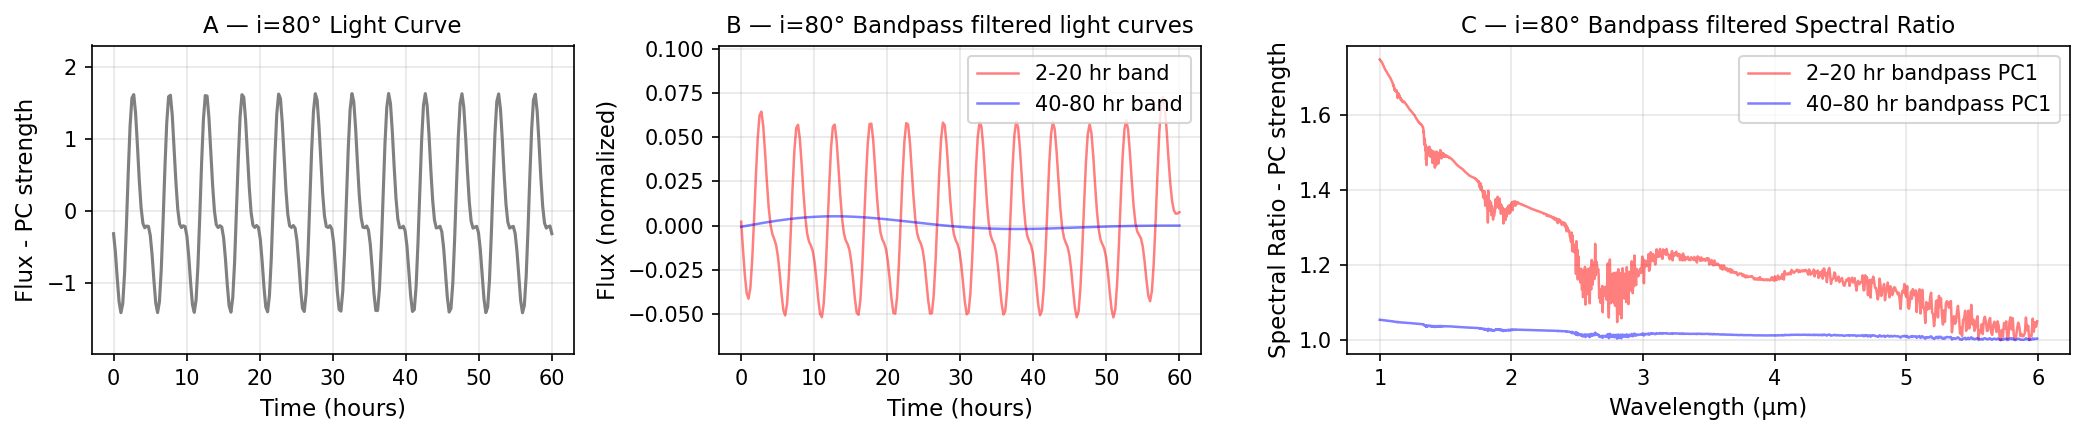

In [23]:
### Plot periodogram analysis for static 60-hour dataset
save = True 
# save = False

fig, axs = plt.subplots(1, 3, figsize=(14, 3), dpi=150, gridspec_kw={'width_ratios': [1, 1, 1.5]})

# plot periodogram of 1.35um light curve
idx_1 = np.argmin(np.abs(wave - 1.35))

# --- Panel A: Periodograms ---
# ax = axs[0]
# lc_1 = flux_normalized_i[:, idx_1] - 1.0
# ls_1 = LombScargle(time_ts, lc_1)
# power_1 = ls_1.power(freqs)
# ax.plot(periods, power_1, color="gray", lw=1.5)
# ax.set_xlabel("Period (hours)", fontsize=11)
# ax.set_ylabel("Lomb-Scargle Power", fontsize=11)
# ax.set_title(f"A — i={incl_key}° Periodogram 1.3-1.4 µm", fontsize=11)
# # draw box around 3-8 hr and 20-100 hr regions
# ax.axvspan(band1_low, band1_high, color='r', alpha=0.1, label=f"{band1_low}-{band1_high} hr band")
# ax.axvspan(band2_low, band2_high, color='b', alpha=0.1, label=f"{band2_low}-{band2_high} hr band")
# ax.legend(fontsize=8)

# --- Panel B: First PCA component over time
ax = axs[0]
pc1_time = X_pca_i[:, 0]
from scipy.signal import savgol_filter
ax.plot(time_ts, savgol_filter(pc1_time, window_length=5, polyorder=3), 
        color="gray", lw=1.5)
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Flux - PC strength", fontsize=11)
ax.set_title(f"A — i={incl_key}° Light Curve", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(1.4*pc1_time.min(), 1.4*pc1_time.max())

# --- Panel C: Bandpass filtered light curves over two bands
ax = axs[1]
lc_5h_1 = filtered_5h[:, idx_1]
lc_60h_1 = filtered_60h[:, idx_1]
ax.plot(time_ts, lc_5h_1,  color="red", lw=1.2, alpha=0.5, label=f"{band1_low}-{band1_high} hr band")
ax.plot(time_ts, lc_60h_1, color="blue", lw=1.2, alpha=0.5, label=f"{band2_low}-{band2_high} hr band")
ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Flux (normalized)", fontsize=11)
ax.set_title(f"B — i={incl_key}° Bandpass filtered light curves", fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ymin = min(lc_5h_1.min(), lc_60h_1.min())
ymax = max(lc_5h_1.max(), lc_60h_1.max())
ax.set_ylim(1.4 * ymin, 1.4 * ymax)

plt.tight_layout()

# --- Panel D: PCA over wavelengths of bandpass filtered data ---
ax = axs[2]
# use the first PCA component from each bandpass filtered data
score_60h_pc1 = scores_60h[:, 0]
score_5h_pc1 = scores_5h[:, 0]

# flip y axis of 5h score and move minimum to 0
score_5h_pc1 = 1+ score_5h_pc1 - np.min(score_5h_pc1) 
# move minimum of 60h score to 0
score_60h_pc1 = 1+ score_60h_pc1 - np.min(score_60h_pc1)
ax.grid(True, alpha=0.3)
ax.plot(wave, score_5h_pc1,  color="red", lw=1.2, alpha=0.5, label=f"{band1_low}–{band1_high} hr bandpass PC1")
ax.plot(wave, score_60h_pc1, color="blue", lw=1.2, alpha=0.5, label=f"{band2_low}–{band2_high} hr bandpass PC1")
ax.set_xlabel("Wavelength (µm)", fontsize=11)
ax.set_ylabel("Spectral Ratio - PC strength", fontsize=11)
ax.set_title(f"C — i={incl_key}° Bandpass filtered Spectral Ratio", fontsize=11)
ax.legend(fontsize=10, loc='upper right')


plt.tight_layout()
if save:
    handle = f'PCA_i={incl_key}_bandpass_filter.pdf'
    save_path = os.path.join(plotDir, handle)
    plt.savefig(save_path, dpi=500, bbox_inches='tight')
plt.show()
plt.close(fig)